# Grundlagen der Künstlichen Intelligenz.
# Exercise 7. Regression

**Autor:** Arturo Olivares Martos
***

- **Asignatura:** Grundlagen der Künstlichen Intelligenz.
- **Curso Académico:** 2025-26.
- **Grado:** Doble Grado en Ingeniería Informática y Matemáticas.
- **Grupo:** Erasmus.
- **Profesor:** Gérald Kämmerer
- **Descripción:** Práctica 7 de la asignatura GKI
<!--- **Fecha:** 17 de abril de 2023. -->
<!-- - **Duración:** -->

## Cereals Dataset: Regression Analysis

We will use the cereals dataset to build and evaluate regression models for
predicting calorie content based on other nutritional characteristics.

Load the `cereal.csv` dataset into a Pandas DataFrame using `pd.read_csv()`.

                        name mfr type  calories  protein  fat  sodium  fiber  \
0                  100% Bran   N    C        70        4    1     130   10.0   
1          100% Natural Bran   Q    C       120        3    5      15    2.0   
2                   All-Bran   K    C        70        4    1     260    9.0   
3  All-Bran with Extra Fiber   K    C        50        4    0     140   14.0   
4             Almond Delight   R    C       110        2    2     200    1.0   

   carbo  sugars  potass  vitamins  shelf  weight  cups     rating  
0    5.0       6     280        25      3     1.0  0.33  68.402973  
1    8.0       8     135         0      3     1.0  1.00  33.983679  
2    7.0       5     320        25      3     1.0  0.33  59.425505  
3    8.0       0     330        25      3     1.0  0.50  93.704912  
4   14.0       8      -1        25      3     1.0  0.75  34.384843  
<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 16 columns):
 #   Column  

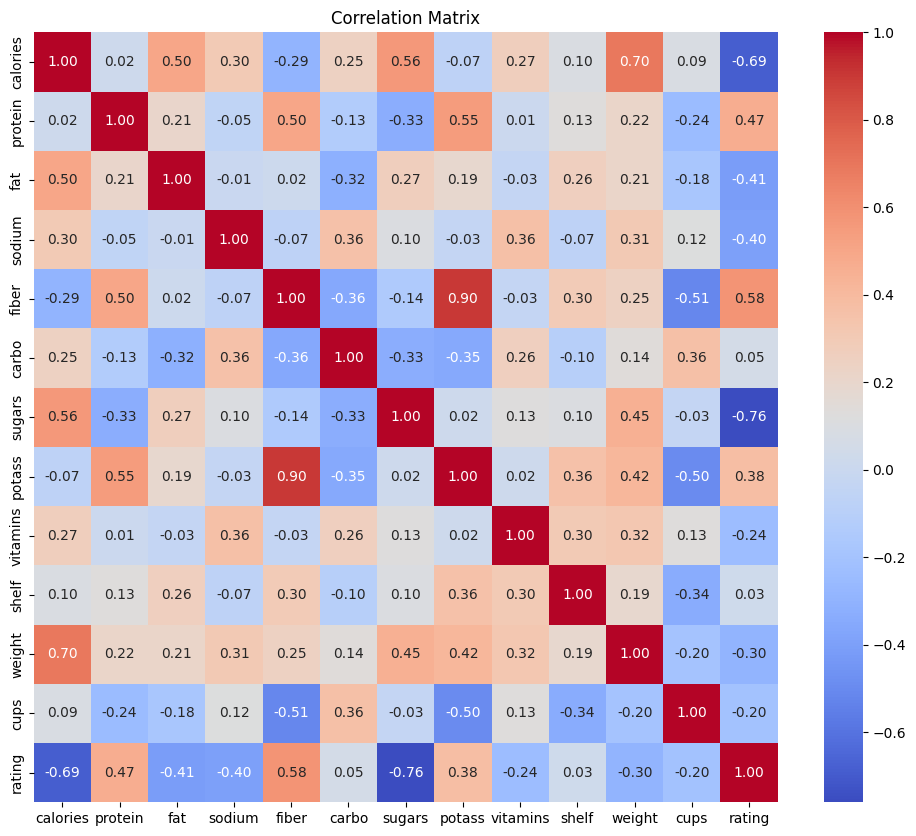

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./Aux/cereal.csv')

# Display the first few rows of the dataset
print(df.head())

# Display the column names and data types
print(df.info())

# Display summary statistics of the dataset
print(df.describe())

# Correlation matrix
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Select features (e.g., sugars, protein) and the target variable (calories) for regression analysis.

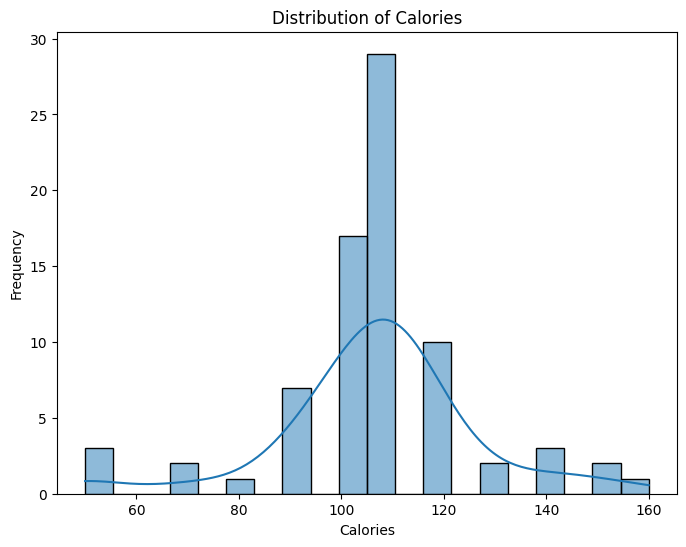

Features (X):
   sugars  protein
0       6        4
1       8        3
2       5        4
3       0        4
4       8        2

Target (y):
0     70
1    120
2     70
3     50
4    110
Name: calories, dtype: int64


In [2]:
target_variable = 'calories'
features = ['sugars', 'protein']  # Example features for regression analysis

# Distribution of the target variable (calories)
target_variable = 'calories'
plt.figure(figsize=(8, 6))
sns.histplot(df[target_variable], bins=20, kde=True)
plt.title('Distribution of Calories')
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.show()

# Creating feature and target datasets
X = df[features]
y = df[target_variable]

# Checking the selected data
print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Split the dataset into training and testing sets using `train_test_split()`. Use 80% of
the data for training and 20% for testing.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Checking the shapes of the training and testing sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (61, 2)
X_test shape: (16, 2)
y_train shape: (61,)
y_test shape: (16,)


Create a linear regression model using `LinearRegression()`, and train the linear regression model using the training data with `model.fit()`.

In [4]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Output the coefficients of the linear regression model
print("Coefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

Coefficients: [2.84137124 4.57420964]
Intercept: 75.82038753757536


Make predictions on the test set using `model.predict()`. Evaluate the model’s performance using metrics like Mean Squared Error (MSE) and R-squared (R2) using `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

In [5]:
predictions = linear_model.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 203.65556671923832
R-squared: 0.31759391256380876


Visualize the predicted vs. actual values using a scatter plot. Add a line representing
perfect predictions for comparison.

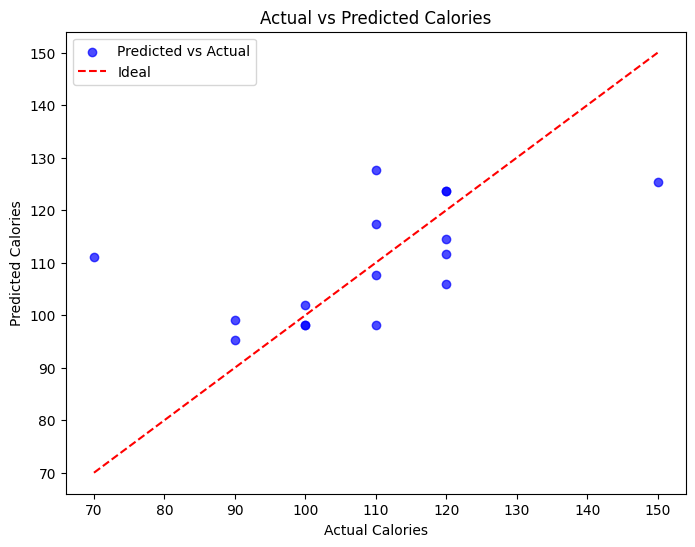

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.7, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.title('Actual vs Predicted Calories')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.legend()
plt.show()

Investigate the coefficients of the linear regression model. What do they tell you about
the relationship between features and the target variable? Extract the formula of the
regression.

In [7]:
print("Coefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

formula = target_variable + " = "
for i, feature in enumerate(features):
    formula += f"({linear_model.coef_[i]:.2f} * {feature}) + "
formula += f"{linear_model.intercept_:.2f}"

print("Linear Regression Formula:")
print("\t" + formula)

Coefficients: [2.84137124 4.57420964]
Intercept: 75.82038753757536
Linear Regression Formula:
	calories = (2.84 * sugars) + (4.57 * protein) + 75.82


Try a Multidimensional Representation of the data. Represent the real points and the predicted points in a 3D scatter plot, and represent the hyperplane of the regression.

In [38]:
if (len(features) != 2):
    raise ValueError("For 3D visualization, exactly 2 features are required. Please adjust the 'features' list accordingly.")
    
import plotly.graph_objects as go

fig = go.Figure()

names = df.loc[X_test.index, 'name']

# Create the actual points (Blue)
fig.add_trace(go.Scatter3d(
    x=X_test[features[0]],
    y=X_test[features[1]],
    z=y_test,
    mode='markers',
    text=names,
    hovertemplate=(
        f"<b>%{{text}}</b><br>"
        f"X ({features[0].capitalize()}): %{{x}}<br>"
        f"Y ({features[1].capitalize()}): %{{y}}<br>"
        f"Real Z ({target_variable.capitalize()}): %{{z}}<extra></extra>"
    ),
    marker=dict(size=5, color='blue', opacity=0.7),
    name='Actual'
))


# Create the predicted points (Red)
fig.add_trace(go.Scatter3d(
    x=X_test[features[0]],
    y=X_test[features[1]],
    z=predictions,
    mode='markers',
    text=names,
    hovertemplate=(
        f"<b>%{{text}}</b><br>"
        f"X ({features[0].capitalize()}): %{{x}}<br>"
        f"Y ({features[1].capitalize()}): %{{y}}<br>"
        f"Predicted Z ({target_variable.capitalize()}): %{{z}}<extra></extra>"
    ),
    marker=dict(size=5, color='red', opacity=0.7),
    name='Predicted'
))

# Add lines connecting actual and predicted points
for i in range(len(X_test)):
    x_val = X_test[features[0]].iloc[i]
    y_val = X_test[features[1]].iloc[i]
    
    fig.add_trace(go.Scatter3d(
        x=[x_val, x_val],
        y=[y_val, y_val],
        z=[y_test.iloc[i], predictions[i]],
        mode='lines',
        line=dict(color='gray', width=1.5),
        showlegend=False, # To avoid cluttering the legend with line entries
        hoverinfo='skip'  # Skip hover info for lines to focus on points
    ))


import numpy as np
# ---------------------------------------------------------------------------
# NEW: Generate and add the Hyperplane using the Mathematical Formula
# ---------------------------------------------------------------------------

# 1. Define the plane boundaries based on your test data
x_min, x_max = X_test[features[0]].min(), X_test[features[0]].max()
y_min, y_max = X_test[features[1]].min(), X_test[features[1]].max()

# 2. Create the 2D grid of points
x_range = np.linspace(x_min, x_max, 20)
y_range = np.linspace(y_min, y_max, 20)
x_grid, y_grid = np.meshgrid(x_range, y_range)

# 3. Apply the plane formula: Z = (coef_1 * X) + (coef_2 * Y) + intercept
# This calculates the height (Calories) for each coordinate on the grid
z_grid = (linear_model.coef_[0] * x_grid) + (linear_model.coef_[1] * y_grid) + linear_model.intercept_

# 4. Add the plane surface to the interactive plot
fig.add_trace(go.Surface(
    x=x_range,
    y=y_range,
    z=z_grid,
    colorscale='Greens',       # Semi-transparent green color for the plane
    opacity=0.4,               # Low opacity to keep the points visible
    name='Regression Plane',
    showscale=False,           # Hide the color scale bar on the side
    hoverinfo='skip',          # Disable any hover action/text on the surface
    contours=dict(             # Disable projection spikes/lines on the 3D axis walls
        x=dict(project=dict(x=False)),
        y=dict(project=dict(y=False)),
        z=dict(project=dict(z=False))
    )
))

# Update layout for better visualization
fig.update_layout(
    title='3D Scatter Plot of Actual vs Predicted Calories',
    scene=dict(
        xaxis_title=features[0],
        yaxis_title=features[1],
        zaxis_title=target_variable
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Render the plot in the browser
fig.show(renderer="browser")
print("3D scatter plot with regression plane has been displayed in the browser.")

3D scatter plot with regression plane has been displayed in the browser.


Experiment with adding or removing features from the model. How does this affect the
model’s performance?

Results with additional feature 'fiber':
Mean Squared Error (MSE): 122.27013973984734
R²-Score: 0.5902990082015587


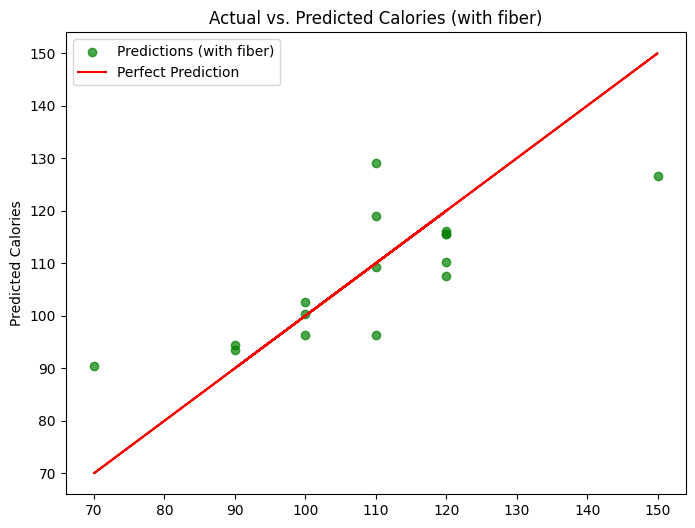

Coefficients of the new model: [ 2.83598161  7.54005559 -3.12937733]
Intercept: 74.57114692863445

New regression formula:
Calories = 74.57 + (2.84 * sugars) + (7.54 * protein) + (-3.13 * fiber)

Interpretation of new coefficients:
An increase of 1 unit in 'sugars' leads to a change of 2.84 in the predicted calories.
An increase of 1 unit in 'protein' leads to a change of 7.54 in the predicted calories.
An increase of 1 unit in 'fiber' leads to a change of -3.13 in the predicted calories.


In [41]:
features_experiment = ['sugars', 'protein', 'fiber']
X_experiment = df[features_experiment]
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_experiment, y, test_size=0.2, random_state=42)
linear_model_exp = LinearRegression()
linear_model_exp.fit(X_train_exp, y_train_exp)
predictions_exp = linear_model_exp.predict(X_test_exp)
mse_exp = mean_squared_error(y_test_exp, predictions_exp)
r2_exp = r2_score(y_test_exp, predictions_exp)

print("Results with additional feature 'fiber':")
print("Mean Squared Error (MSE):", mse_exp)
print("R²-Score:", r2_exp)

# Visualizing actual vs predicted values for the new model
plt.figure(figsize=(8, 6))
plt.scatter(y_test_exp, predictions_exp, alpha=0.7, color='green', label='Predictions (with fiber)')
plt.plot(y_test_exp, y_test_exp, color='red', label='Perfect Prediction')  # Perfect prediction line
plt.ylabel('Predicted Calories')
plt.title('Actual vs. Predicted Calories (with fiber)')
plt.legend()
plt.show()

# Output the coefficients of the new linear regression model with the additional feature
print("Coefficients of the new model:", linear_model_exp.coef_)
print("Intercept:", linear_model_exp.intercept_)

# Deriving the new regression formula
print("\nNew regression formula:")
formula_exp = f"Calories = {linear_model_exp.intercept_:.2f}"
for coef, feature in zip(linear_model_exp.coef_, features_experiment):
    formula_exp += f" + ({coef:.2f} * {feature})"
print(formula_exp)

# Interpretation of new coefficients
print("\nInterpretation of new coefficients:")
for coef, feature in zip(linear_model_exp.coef_, features_experiment):
    print(f"An increase of 1 unit in '{feature}' leads to a change of {coef:.2f} in the predicted calories.")

## L1 and L2 Regularization Comparison

Create Ridge and Lasso regression models using `Ridge()` and `Lasso()`.
- Experiment with different alpha values (regularization strength).
- Train the Ridge and Lasso models on the training data.
- Make predictions on the test set using both models.
- Evaluate the performance of both models using MSE and R2.
- Compare the coefficients of the Ridge and Lasso models. How do they differ? What does
this tell you about feature selection?
- Visualize the coefficients of the Ridge and Lasso models using bar plots.

Ridge Regression Results:
	- Alpha: 0.1
		- MSE: 203.6197
		- R²: 0.3177
		- Coefficients: [2.84059138 4.56713776]
		- Intercept: 75.8438
	- Alpha: 1.0
		- MSE: 203.3051
		- R²: 0.3188
		- Coefficients: [2.8336503 4.5044255]
		- Intercept: 76.0520
	- Alpha: 10.0
		- MSE: 200.8406
		- R²: 0.3270
		- Coefficients: [2.77094401 3.95785338]
		- Intercept: 77.8810
	- Alpha: 50.0
		- MSE: 196.8136
		- R²: 0.3405
		- Coefficients: [2.57822526 2.54634344]
		- Intercept: 82.8071
	- Alpha: 100.0
		- MSE: 196.1860
		- R²: 0.3426
		- Coefficients: [2.42158989 1.73511128]
		- Intercept: 85.9405

Lasso Regression Results:
	- Alpha: 0.1
		- MSE: 203.1669
		- R²: 0.3192
		- Coefficients: [2.82880592 4.47710327]
		- Intercept: 76.1547
	- Alpha: 1.0
		- MSE: 199.4988
		- R²: 0.3315
		- Coefficients: [2.71597348 3.60346113]
		- Intercept: 79.1612
	- Alpha: 10.0
		- MSE: 200.5560
		- R²: 0.3280
		- Coefficients: [1.98195123 0.        ]
		- Intercept: 93.3321
	- Alpha: 50.0
		- MSE: 303.9909
		- R²: -0.0186

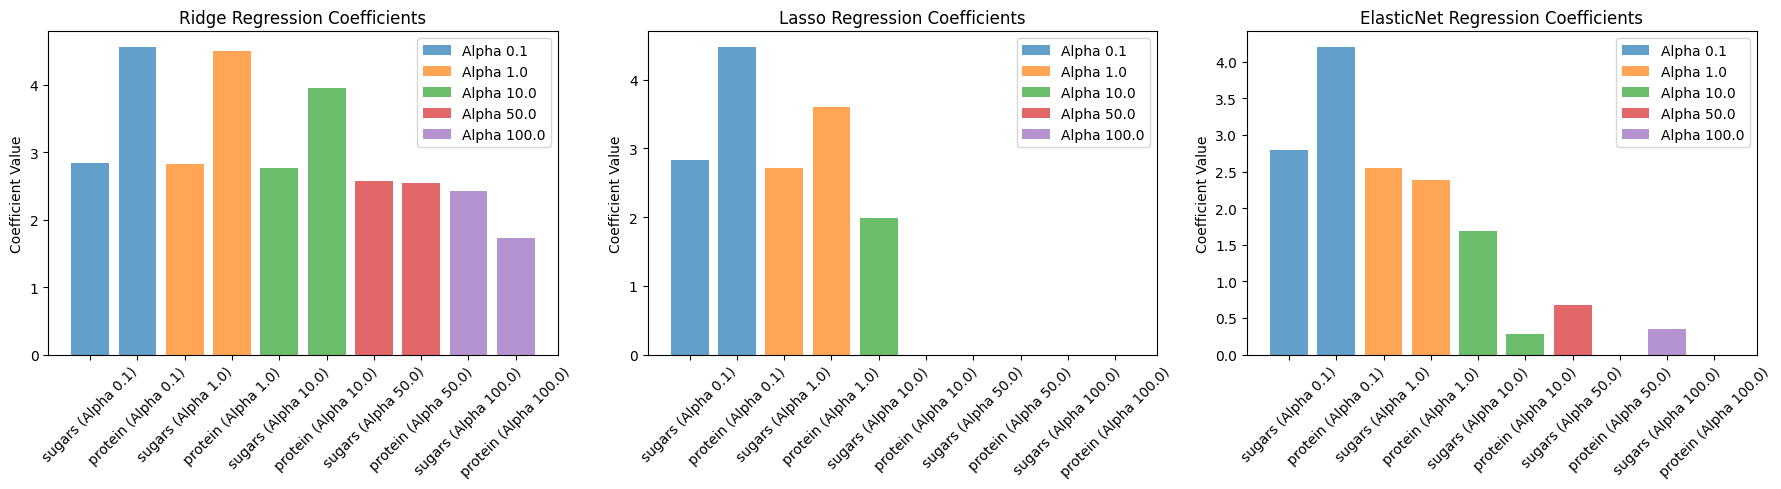

In [51]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
alpha_values = [0.1, 1.0, 10.0, 50.0, 100.0]
ridge_models = {}
lasso_models = {}
elasticnet_models = {}

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    lasso = Lasso(alpha=alpha)
    elasticnet = ElasticNet(alpha=alpha, l1_ratio=0.1)
    ridge.fit(X_train, y_train)
    lasso.fit(X_train, y_train)
    elasticnet.fit(X_train, y_train)
    predictions_ridge = ridge.predict(X_test)
    predictions_lasso = lasso.predict(X_test)
    predictions_elasticnet = elasticnet.predict(X_test)
    mse_ridge = mean_squared_error(y_test, predictions_ridge)
    mse_lasso = mean_squared_error(y_test, predictions_lasso)
    mse_elasticnet = mean_squared_error(y_test, predictions_elasticnet)
    r2_ridge = r2_score(y_test, predictions_ridge)
    r2_lasso = r2_score(y_test, predictions_lasso)
    r2_elasticnet = r2_score(y_test, predictions_elasticnet)
    ridge_models[alpha] = {
        'MSE': mse_ridge,
        'R²': r2_ridge,
        'Coefficients': ridge.coef_,
        'Intercept': ridge.intercept_
    }
    lasso_models[alpha] = {
        'MSE': mse_lasso,
        'R²': r2_lasso,
        'Coefficients': lasso.coef_,
        'Intercept': lasso.intercept_
    }
    elasticnet_models[alpha] = {
        'MSE': mse_elasticnet,
        'R²': r2_elasticnet,
        'Coefficients': elasticnet.coef_,
        'Intercept': elasticnet.intercept_
    }

print("Ridge Regression Results:")
for alpha, metrics in ridge_models.items():
    print(f"\t- Alpha: {alpha}")
    print(f"\t\t- MSE: {metrics['MSE']:.4f}")
    print(f"\t\t- R²: {metrics['R²']:.4f}")
    print(f"\t\t- Coefficients: {metrics['Coefficients']}")
    print(f"\t\t- Intercept: {metrics['Intercept']:.4f}")
print("\nLasso Regression Results:")
for alpha, metrics in lasso_models.items():
    print(f"\t- Alpha: {alpha}")
    print(f"\t\t- MSE: {metrics['MSE']:.4f}")
    print(f"\t\t- R²: {metrics['R²']:.4f}")
    print(f"\t\t- Coefficients: {metrics['Coefficients']}")
    print(f"\t\t- Intercept: {metrics['Intercept']:.4f}")
print("\nElasticNet Regression Results:")
for alpha, metrics in elasticnet_models.items():
    print(f"\t- Alpha: {alpha}")
    print(f"\t\t- MSE: {metrics['MSE']:.4f}")
    print(f"\t\t- R²: {metrics['R²']:.4f}")
    print(f"\t\t- Coefficients: {metrics['Coefficients']}")
    print(f"\t\t- Intercept: {metrics['Intercept']:.4f}")

# Visualize the results of Ridge and Lasso regression
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.title('Ridge Regression Coefficients')
for alpha in alpha_values:
    plt.bar([f"{feature} (Alpha {alpha})" for feature in features], ridge_models[alpha]['Coefficients'], alpha=0.7, label=f'Alpha {alpha}')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1, 3, 2)
plt.title('Lasso Regression Coefficients')
for alpha in alpha_values:
    plt.bar([f"{feature} (Alpha {alpha})" for feature in features], lasso_models[alpha]['Coefficients'], alpha=0.7, label=f'Alpha {alpha}')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.legend()

plt.subplot(1, 3, 3)
plt.title('ElasticNet Regression Coefficients')
for alpha in alpha_values:
    plt.bar([f"{feature} (Alpha {alpha})" for feature in features], elasticnet_models[alpha]['Coefficients'], alpha=0.7, label=f'Alpha {alpha}')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

As we can see, the Lasso regression can lead to sparse models where some coefficients are exactly zero, effectively performing feature selection. In contrast, Ridge regression tends to shrink coefficients but does not set them to zero, which can be useful when we want to keep all features in the model.